# 🧠 Semaine 2 — Jour 4 : Gestion de Dialogue & Session

## Objectif : Comprendre et implémenter le lien entre mémoire courte, session state et mémoire longue.

Dans les systèmes de type agent IA (OpenAI, LangChain, etc.), la **gestion du contexte conversationnel** repose sur plusieurs niveaux de mémoire :

1. **Mémoire courte (Context Window)** : ce que le modèle peut lire directement (souvent limitée à 8K–200K tokens).
2. **Session state** : mémoire maintenue temporairement côté client ou serveur, pendant la session.
3. **Mémoire longue** : stockage persistant (fichiers, base vectorielle, base de données, etc.).

L’agent doit gérer le *glissement de la fenêtre de contexte* et la *synchronisation entre ces mémoires*.

In [1]:
import json
from collections import deque

# --- Définition des trois types de mémoire --- #
class ShortTermMemory:
    def __init__(self, max_messages=5):
        self.messages = deque(maxlen=max_messages)
    
    def add(self, role, content):
        self.messages.append({"role": role, "content": content})
    
    def get(self):
        return list(self.messages)

class SessionState:
    def __init__(self):
        self.state = {}
    
    def update(self, key, value):
        self.state[key] = value
    
    def get(self, key):
        return self.state.get(key)

class LongTermMemory:
    def __init__(self, path="long_memory.json"):
        self.path = path
        try:
            with open(path, 'r') as f:
                self.data = json.load(f)
        except FileNotFoundError:
            self.data = {}
    
    def save_memory(self):
        with open(self.path, 'w') as f:
            json.dump(self.data, f, indent=2)
    
    def add_fact(self, user, fact):
        self.data.setdefault(user, []).append(fact)
        self.save_memory()
    
    def recall(self, user):
        return self.data.get(user, [])

In [2]:
# --- Exemple d'agent minimal --- #
class ConversationalAgent:
    def __init__(self, user="user1"):
        self.short = ShortTermMemory(max_messages=3)
        self.session = SessionState()
        self.long = LongTermMemory()
        self.user = user
        
    def respond(self, user_input):
        # Ajouter à la mémoire courte
        self.short.add("user", user_input)
        
        # Exemple simple : déduire une réponse basique
        if "nom" in user_input.lower():
            response = "Je m'appelle AgentPy. Et toi ?"
        elif "rappelle" in user_input.lower():
            facts = self.long.recall(self.user)
            response = f"Je me souviens de ceci : {facts}" if facts else "Je n'ai encore rien retenu de toi."
        elif "je suis" in user_input.lower():
            self.long.add_fact(self.user, user_input)
            response = "Bien noté, je m'en souviendrai pour plus tard."
        else:
            response = "Je t'écoute."
        
        self.short.add("assistant", response)
        return response

In [3]:
# --- Simulation d'une conversation --- #
agent = ConversationalAgent()

dialogue = [
    "Bonjour !",
    "Je suis Stéphane",
    "Quel est ton nom ?",
    "Rappelle-toi qui je suis",
    "Rappelle-toi qui je suis"
]

for msg in dialogue:
    print(f"👤 {msg}")
    print(f"🤖 {agent.respond(msg)}\n")

👤 Bonjour !
🤖 Je t'écoute.

👤 Je suis Stéphane
🤖 Bien noté, je m'en souviendrai pour plus tard.

👤 Quel est ton nom ?
🤖 Je m'appelle AgentPy. Et toi ?

👤 Rappelle-toi qui je suis
🤖 Je me souviens de ceci : ['Je suis Stéphane']

👤 Rappelle-toi qui je suis
🤖 Je me souviens de ceci : ['Je suis Stéphane']



## 🧩 Visualisation du glissement de fenêtre (mémoire courte)

Le graphique ci-dessous montre comment la mémoire courte (fenêtre de contexte) se déplace au fur et à mesure des échanges : seuls les derniers messages restent accessibles au modèle.

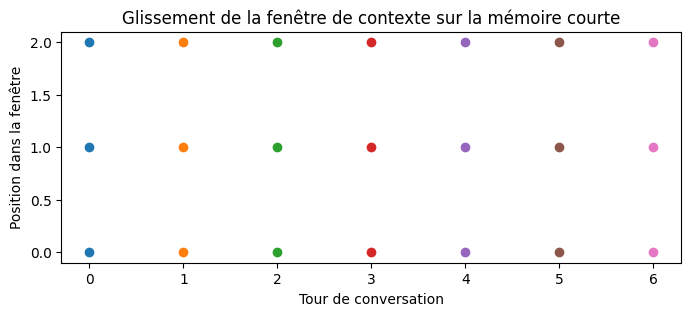

In [4]:
import matplotlib.pyplot as plt

# Exemple de fenêtre glissante de 3 tours
messages = [f"Message {i}" for i in range(1, 10)]
window_size = 3

plt.figure(figsize=(8, 3))
for i in range(len(messages) - window_size + 1):
    window = messages[i:i+window_size]
    plt.plot([i]*len(window), range(window_size), 'o')

plt.title("Glissement de la fenêtre de contexte sur la mémoire courte")
plt.xlabel("Tour de conversation")
plt.ylabel("Position dans la fenêtre")
plt.show()

### 🧩 Points clés :
- La **mémoire courte** ne conserve qu’un nombre limité de messages.
- La **session state** peut stocker des variables de session (thèmes, préférences, etc.).
- La **mémoire longue** est persistante entre les sessions.

Cette structure peut ensuite être enrichie avec :
- Un stockage vectoriel (FAISS, Chroma, etc.) pour la mémoire longue.
- Une intégration avec les API OpenAI ou LangChain (`ConversationBufferMemory`, `ConversationSummaryMemory`).